In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [3]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()

p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6
DPP = 1e-4


In [4]:
# Proton mass in GeV/c^2
proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9

# Beam energy in GeV
beam_energy_GeV = 400

# Compute gamma
gamma = beam_energy_GeV / proton_mass_GeV
print(f"Gamma: {gamma}")

Gamma: 426.3155693395322


In [5]:
EX = N_EX / gamma
print(f"EX: {EX}")

EX: 2.3456802235706435e-08


In [6]:
deltaP_P = 1e-3
print(f"deltaP_P: {deltaP_P}")

deltaP_P: 0.001


## Uploading the sequence

In [42]:
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)




#septa_names_with_apertures = install_septa(line, install_zs=True)
#line.cycle("bpcn.20902", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

In [43]:
tw_init = line.twiss(method='4d')
print(tw_init.qx)
print(tw_init.qy)

22.130000000065145
22.180000000051958


# Imposing max dispersion at TECA 

Rematching the tunes to obtain the maximum horizontal dispersion at the TECA

In [44]:
# Extraction tunes
opt = line.match(solve=False,
                 method='4d',
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
    ],
    targets=[
        xt.TargetSet(qx=22.93, qy=22.18, tol=1e-5),    # Desired target tunes
        #xt.TargetSet(dqx=-1 * 26., dqy=0.47 * 26., tol=1e-3),    # Desired dispersion values
    ])

In [45]:
opt.target_status()
opt.step(20)

Target status:                          
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx    False          -0.8         22.13         22.93 'qx', val=22.93, tol=1e-05, weight=10
1  ON    qy     True   5.19584e-11         22.18         22.18 'qy', val=22.18, tol=1e-05, weight=10
                                             
Optimize - start penalty: 8             
Matching: model call n. 14               
Optimize - end penalty:  1.40124e-06


In [46]:
opt.target_status()
opt.vary_status()

Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True  -1.17751e-07         22.93         22.93 'qx', val=22.93, tol=1e-05, weight=10
1  ON    qy     True  -7.59572e-08         22.18         22.18 'qy', val=22.18, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0128856 None            0.0125751         1e-07             1
1  ON        OK  kqd          None           -0.0126577 None           -0.0125777         1e-07             1
2  ON        OK  qph_setvalue None          1.94775e-14 None                    0        0.0001             1
3  ON        OK  qpv_setvalue None         -2.67083e-14 None                    0        0.0001             1


In [47]:
# Extraction tunes
opt = line.match(solve=False,
                 method='4d',
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
    ],
    targets=[
        xt.TargetSet(qx=22.51, qy=22.43, tol=1e-5),    # Desired target tunes
        #xt.TargetSet(dqx=-1 * 26., dqy=0.47 * 26., tol=1e-3),    # Desired dispersion values
    ])

In [48]:
opt.target_status()
opt.step(20)

Target status:                          
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx    False          0.42         22.93         22.51 'qx', val=22.51, tol=1e-05, weight=10
1  ON    qy    False         -0.25         22.18         22.43 'qy', val=22.43, tol=1e-05, weight=10
                                             
Optimize - start penalty: 4.888         
Matching: model call n. 14               
Optimize - end penalty:  2.35551e-05


In [49]:
opt.target_status()
opt.vary_status()

Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True  -2.35519e-06         22.51         22.51 'qx', val=22.51, tol=1e-05, weight=10
1  ON    qy     True   3.87082e-08         22.43         22.43 'qy', val=22.43, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0127469 None            0.0128856         1e-07             1
1  ON        OK  kqd          None           -0.0127121 None           -0.0126577         1e-07             1
2  ON        OK  qph_setvalue None          2.37104e-14 None          1.94775e-14        0.0001             1
3  ON        OK  qpv_setvalue None         -1.69146e-14 None         -2.67083e-14        0.0001             1


TwissTable: 4605 rows, 62 cols
name                   s             x            px             y            py          zeta ...
sps$start              0             0             0             0             0             0
begi.10010             0             0             0             0             0             0
qf.10010               0             0             0             0             0             0
drift_0            3.085             0             0             0             0             0
mba.10030        3.44499             0             0             0             0             0
drift_1          9.70501  -2.51534e-16  -8.10998e-17             0             0  -3.87468e-14
mba.10050         10.105  -2.83972e-16  -8.10998e-17             0             0  -3.87468e-14
drift_2           16.365  -1.04083e-15  -1.61769e-16             0             0  -7.74936e-14
mbb.10070         16.755  -1.10392e-15  -1.61769e-16             0             0  -7.74936e-14
drift_3        

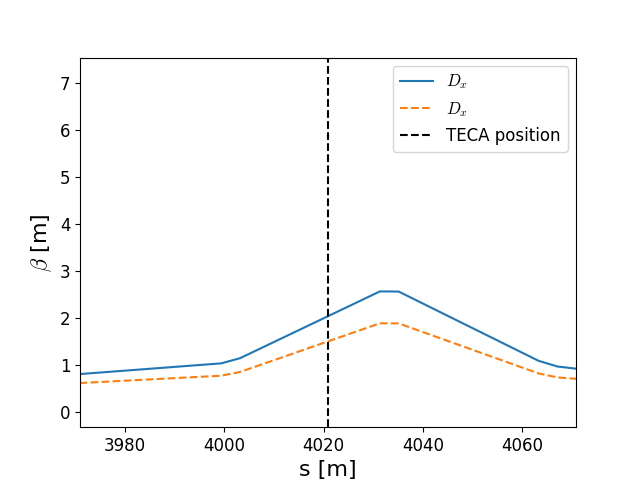

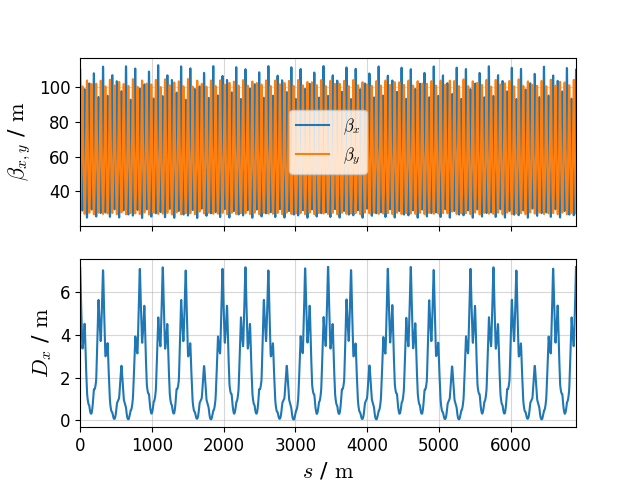

In [50]:
tw = line.twiss(method='4d')
print(tw)

xplt.TwissPlot(tw, kind='bet, dx')
# Limit the plot in the x range close to the marker of the TECA object
teca_marker_position = line.get_table()['s', 'TECA.entry']
x_range = (teca_marker_position - 50, teca_marker_position + 50)


fig, ax = plt.subplots()
#ax.plot(tw['s'], tw['betx'], label=r'$\beta_x$')
#ax.plot(tw['s'], tw['bety'], label=r'$\beta_y$')
ax.plot(tw['s'], tw['dx'], label=r'$D_x$')
ax.plot(tw_init['s'], tw_init['dx'], label=r'$D_x$', linestyle='--')
ax.axvline(teca_marker_position, color='k', linestyle='--', label='TECA position')
ax.set_xlim(x_range)
ax.set_xlabel('s [m]')
ax.set_ylabel(r'$\beta$ [m]')
ax.legend(loc='upper left')
ax.legend()
plt.show()

## Twiss inspection

In [51]:
max_betx = tw_init['betx'].max()
min_betx = tw_init['betx'].min()

print(f"Maximum Beta_x: {max_betx}")
print(f"Minimum Beta_x: {min_betx}")

Maximum Beta_x: 103.37439706617627
Minimum Beta_x: 27.564272621262756


In [52]:
max_dx = tw_init['dx'].max()
min_dx = tw_init['dx'].min()

print(f"Maximum Dispersion in x (dx): {max_dx}")
print(f"Minimum Dispersion in x (dx): {min_dx}")

Maximum Dispersion in x (dx): 6.901491227425078
Minimum Dispersion in x (dx): 0.13786849035183887


In [53]:
teca_entry_s = line.get_table()['s', 'TECA.entry']
beta_x_at_teca = tw_init.rows[np.isclose(tw_init['s'], teca_entry_s)].betx[0]
print(f"Beta_x at TECA position: {beta_x_at_teca}")

Beta_x at TECA position: 65.34071766557256


In [54]:
dx_at_teca = tw_init.rows[np.isclose(tw_init['s'], teca_entry_s)].dx[0]
print(f"Dispersion D_x at TECA position: {dx_at_teca}")

Dispersion D_x at TECA position: 1.5015111937295331


In [55]:
EpsilonBeta = beta_x_at_teca * EX
print(f"Epsilon * Beta (m^2): {EpsilonBeta}")

Epsilon * Beta (m^2): 1.5326842922204652e-06


In [56]:
D_xDeltaP = (dx_at_teca * deltaP_P)*(dx_at_teca * deltaP_P)
print(f"D_x * DeltaP/P: {D_xDeltaP}")

D_x * DeltaP/P: 2.2545358648950875e-06


In [57]:
sigma_xMAX =  np.sqrt(max_betx * EX + max_dx * deltaP_P * max_dx * deltaP_P)
print(f"sigma_xMAX: {sigma_xMAX}")

sigma_xMAX: 0.007074985084821168


In [58]:
# Define the variable names and their values
variable_names = [
    "max_betx", "min_betx", "beta_x_at_teca", "max_dx", "min_dx", "dx_at_teca", 
    "EpsilonBeta", "D_xDeltaP", "sigma_xMAX"
]

variable_values = [
    max_betx, min_betx, beta_x_at_teca, max_dx, min_dx, dx_at_teca, 
    EpsilonBeta, D_xDeltaP, sigma_xMAX
]

# Create the 2D array
twiss_df = np.array([variable_names, variable_values])
print(twiss_df)


[['max_betx' 'min_betx' 'beta_x_at_teca' 'max_dx' 'min_dx' 'dx_at_teca'
  'EpsilonBeta' 'D_xDeltaP' 'sigma_xMAX']
 ['103.37439706617627' '27.564272621262756' '65.34071766557256'
  '6.901491227425078' '0.13786849035183887' '1.5015111937295331'
  '1.5326842922204652e-06' '2.2545358648950875e-06'
  '0.007074985084821168']]
